In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
DATA_PATH = "../data/processed/risk_model_features.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (250025, 9)


In [4]:
df.head()
df.columns

Index(['road_segment_id', 'date', 'rainfall_1d', 'rainfall_3d', 'rainfall_7d',
       'elevation', 'slope', 'landslides_5km', 'landslides_10km'],
      dtype='object')

In [5]:
df.isnull().sum()

road_segment_id    0
date               0
rainfall_1d        0
rainfall_3d        0
rainfall_7d        0
elevation          0
slope              0
landslides_5km     0
landslides_10km    0
dtype: int64

In [6]:
df.describe()

,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
count,250025.000000,250025.000000,250025.000000,250025.000000,250025.000000,250025.000000,250025.000000
mean,5.100746,15.296878,35.678249,424.350433,2.487707,1.427737,3.938686
std,12.539741,28.182407,51.607151,648.341736,4.541761,3.370916,8.642083
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.186943,59.000000,0.175916,0.000000,0.000000
50%,0.000000,3.395078,15.958921,107.625000,0.348116,0.000000,0.000000
75%,4.446642,19.474430,53.326485,592.000000,2.618813,1.000000,2.000000
max,395.557312,759.033813,1071.066162,5135.000000,26.137190,19.000000,33.000000


In [7]:
df["slope"].sort_values(ascending=False).head(20)

41579     26.13719
79939     26.13719
85419     26.13719
183374    26.13719
160769    26.13719
43634     26.13719
117614    26.13719
78569     26.13719
64869     26.13719
29249     26.13719
10069     26.13719
165564    26.13719
199129    26.13719
202554    26.13719
166934    26.13719
76514     26.13719
27879     26.13719
62129     26.13719
228584    26.13719
66239     26.13719
Name: slope, dtype: float32

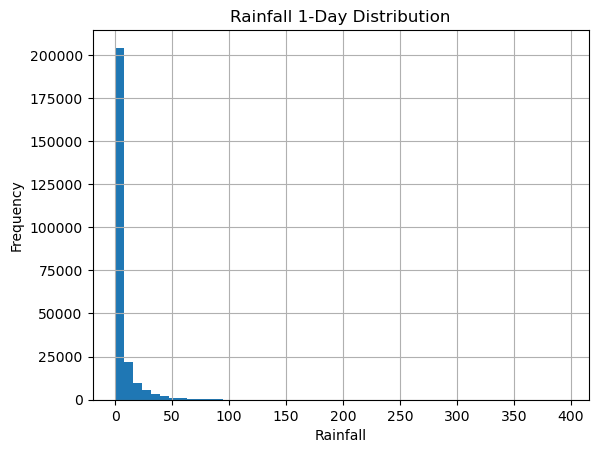

In [8]:
df["rainfall_1d"].hist(bins=50)

plt.title("Rainfall 1-Day Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

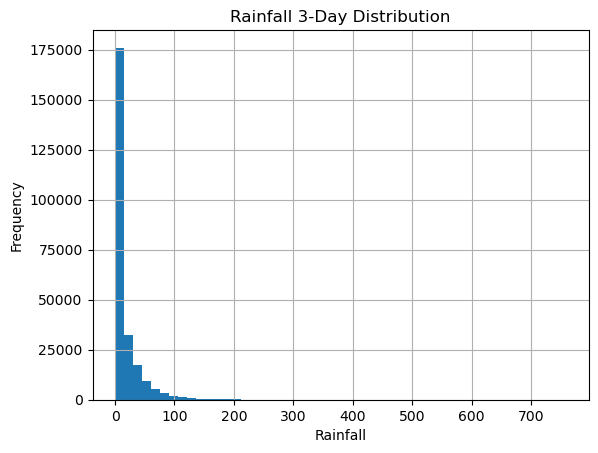

In [9]:
df["rainfall_3d"].hist(bins=50)

plt.title("Rainfall 3-Day Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

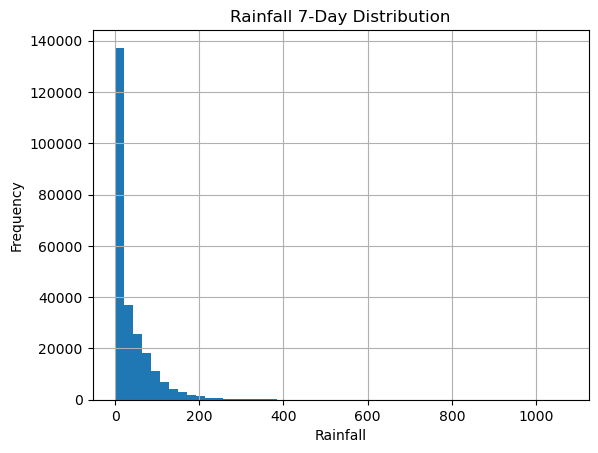

In [10]:
df["rainfall_7d"].hist(bins=50)

plt.title("Rainfall 7-Day Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

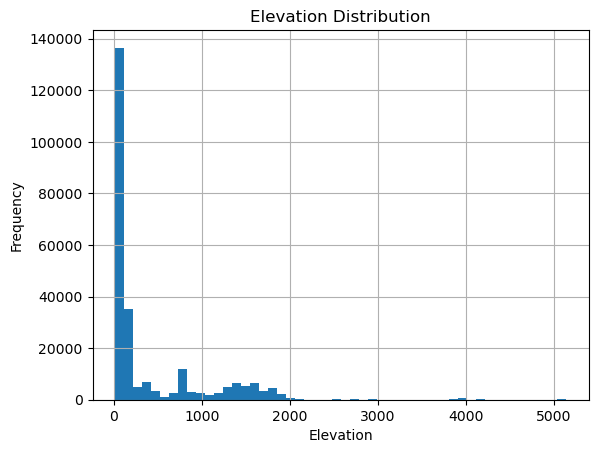

In [11]:
df["elevation"].hist(bins=50)

plt.title("Elevation Distribution")
plt.xlabel("Elevation")
plt.ylabel("Frequency")

plt.show()

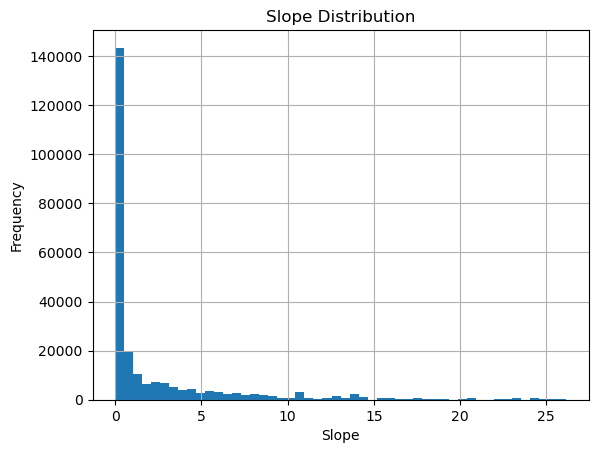

In [12]:
df["slope"].hist(bins=50)

plt.title("Slope Distribution")
plt.xlabel("Slope")
plt.ylabel("Frequency")

plt.show()

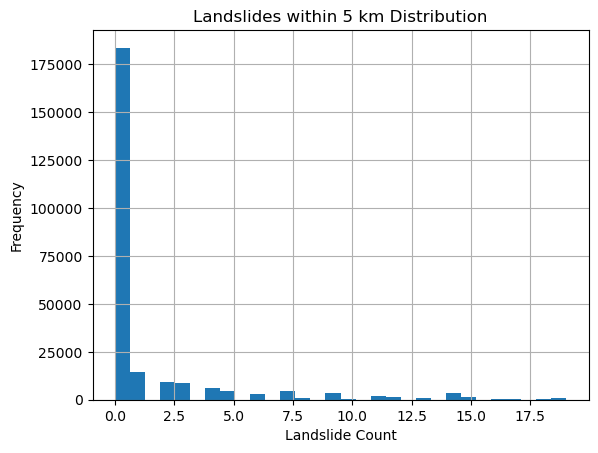

In [13]:
df["landslides_5km"].hist(bins=30)

plt.title("Landslides within 5 km Distribution")
plt.xlabel("Landslide Count")
plt.ylabel("Frequency")

plt.show()

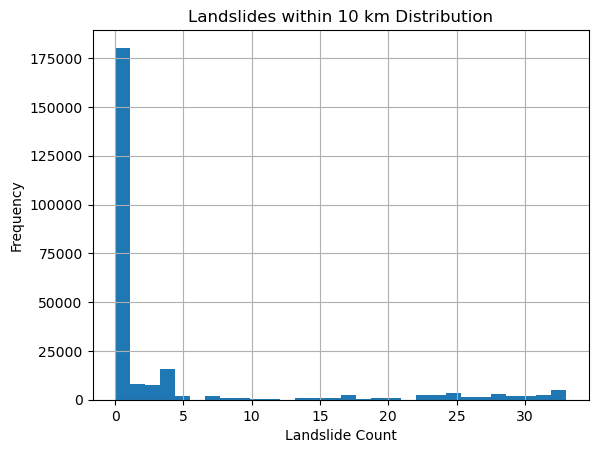

In [14]:
df["landslides_10km"].hist(bins=30)

plt.title("Landslides within 10 km Distribution")
plt.xlabel("Landslide Count")
plt.ylabel("Frequency")

plt.show()

In [15]:
features = [
    "rainfall_1d",
    "rainfall_3d",
    "rainfall_7d",
    "elevation",
    "slope",
    "landslides_5km",
    "landslides_10km"
]

print(features)

['rainfall_1d', 'rainfall_3d', 'rainfall_7d', 'elevation', 'slope', 'landslides_5km', 'landslides_10km']


In [16]:
X = df[features].copy()

print("X shape:", X.shape)
print(X.head())

X shape: (250025, 7)
   rainfall_1d  rainfall_3d  rainfall_7d  elevation      slope  \
0          0.0          0.0          0.0     54.500   1.316799   
1          0.0          0.0          0.0    314.750  10.976639   
2          0.0          0.0          0.0    660.625   6.031606   
3          0.0          0.0          0.0    803.000   2.731146   
4          0.0          0.0          0.0   1738.375  18.646812   

   landslides_5km  landslides_10km  
0               3               18  
1               2                3  
2               0                0  
3               1                2  
4               5                5  


In [17]:
print("Missing values:")
print(X.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X).sum())

Missing values:
rainfall_1d        0
rainfall_3d        0
rainfall_7d        0
elevation          0
slope              0
landslides_5km     0
landslides_10km    0
dtype: int64

Infinite values:
rainfall_1d        0
rainfall_3d        0
rainfall_7d        0
elevation          0
slope              0
landslides_5km     0
landslides_10km    0
dtype: int64


In [18]:
X.dtypes

rainfall_1d        float32
rainfall_3d        float32
rainfall_7d        float32
elevation          float32
slope              float32
landslides_5km       int16
landslides_10km      int16
dtype: object

In [19]:
X.nunique()

rainfall_1d        30262
rainfall_3d        36922
rainfall_7d        39699
elevation            494
slope                679
landslides_5km        20
landslides_10km       30
dtype: int64

In [20]:
X.agg(["min", "max", "mean", "std"]).T

,min,max,mean,std
rainfall_1d,0.0,395.557312,5.100746,12.539741
rainfall_3d,0.0,759.033813,15.296878,28.182407
rainfall_7d,0.0,1071.066162,35.678249,51.607151
elevation,12.0,5135.000000,424.350433,648.341736
slope,0.0,26.137190,2.487707,4.541761
landslides_5km,0.0,19.000000,1.427737,3.370916
landslides_10km,0.0,33.000000,3.938686,8.642083


In [21]:
X.corr()

,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
rainfall_1d,1.000000,0.728360,0.528904,0.019224,0.034807,-0.040511,-0.048061
rainfall_3d,0.728360,1.000000,0.775876,0.025703,0.046473,-0.053960,-0.064023
rainfall_7d,0.528904,0.775876,1.000000,0.032809,0.059245,-0.068614,-0.081420
elevation,0.019224,0.025703,0.032809,1.000000,0.590679,-0.044401,-0.098720
slope,0.034807,0.046473,0.059245,0.590679,1.000000,0.010165,-0.008743
landslides_5km,-0.040511,-0.053960,-0.068614,-0.044401,0.010165,1.000000,0.896258
landslides_10km,-0.048061,-0.064023,-0.081420,-0.098720,-0.008743,0.896258,1.000000


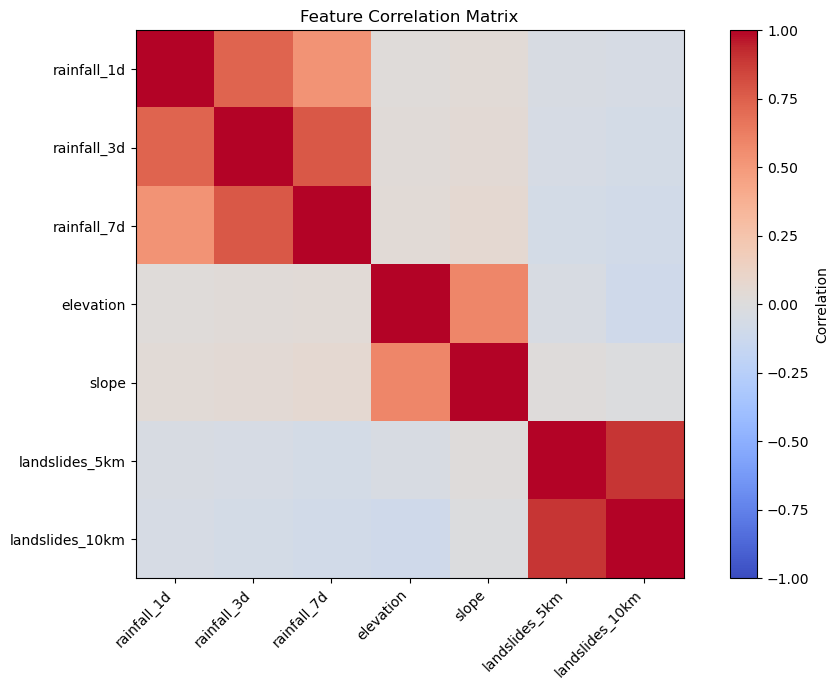

In [22]:
plt.figure(figsize=(10, 7))

plt.imshow(X.corr(), cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(X.columns)),
    X.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [23]:
X_model = X.copy()

print("Model input shape:", X_model.shape)
print("Model input columns:")
print(X_model.columns.tolist())

Model input shape: (250025, 7)
Model input columns:
['rainfall_1d', 'rainfall_3d', 'rainfall_7d', 'elevation', 'slope', 'landslides_5km', 'landslides_10km']


In [24]:
X_model = X.copy()

print("Scaling: NOT required")
print("Final features:", X_model.shape)

Scaling: NOT required
Final features: (250025, 7)


In [25]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

print(model)

IsolationForest(n_estimators=200, n_jobs=-1, random_state=42)


In [26]:
model.fit(X_model)

print("Isolation Forest training completed successfully")

Isolation Forest training completed successfully


In [28]:
anomaly_scores = model.decision_function(X_model)

print("Anomaly scores generated successfully")
print("Number of scores:", len(anomaly_scores))

Anomaly scores generated successfully
Number of scores: 250025


In [29]:
print("Minimum:", anomaly_scores.min())
print("Maximum:", anomaly_scores.max())
print("Mean:", anomaly_scores.mean())
print("Median:", np.median(anomaly_scores))

Minimum: -0.2990846743322392
Maximum: 0.1723371308995792
Mean: 0.08941559605502916
Median: 0.11260453204294152


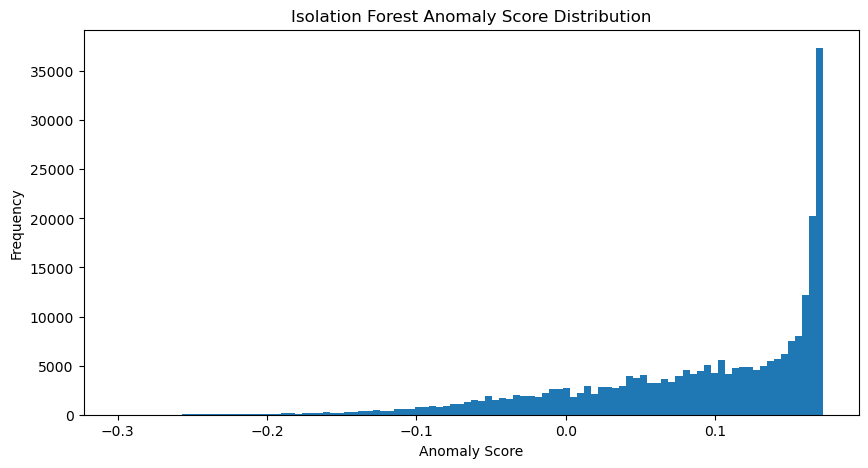

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(anomaly_scores, bins=100)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")

plt.show()

In [31]:
np.percentile(
    anomaly_scores,
    [0, 1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99, 100]
)

array([-0.29908467, -0.15047284, -0.11685765, -0.07094627, -0.03292019,
        0.04049878,  0.11260453,  0.16129492,  0.16950899,  0.17121024,
        0.17169108,  0.17184823,  0.17233713])

In [32]:
top_anomalies = df.loc[
    np.argsort(anomaly_scores)[:20],
    [
        "road_segment_id",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "elevation",
        "slope",
        "landslides_5km",
        "landslides_10km"
    ]
]

top_anomalies


,road_segment_id,date,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
189803,road_7158,2025-10-05,223.761597,247.282089,324.216400,2071.000,22.858677,7,11
189806,road_7293,2025-10-05,177.441284,189.929169,279.703308,1441.250,18.959938,8,9
137058,road_7158,2025-07-20,86.697289,143.703140,266.857544,2071.000,22.858677,7,11
190350,road_69769,2025-10-05,223.761597,247.282089,324.216400,3946.000,6.736553,0,2
189749,road_552,2025-10-05,177.441284,189.929169,279.703308,1738.375,18.646812,5,5
176788,road_7158,2025-09-16,72.617210,143.979370,207.554214,2071.000,22.858677,7,11
154183,road_7158,2025-08-14,84.021011,126.986198,220.282486,2071.000,22.858677,7,11
189746,road_249,2025-10-05,297.044708,319.085876,444.212463,314.750,10.976639,2,3
189839,road_10643,2025-10-05,177.441284,189.929169,279.703308,1660.000,7.371905,8,9
102956,road_23318,2025-05-31,154.303024,308.179230,365.619171,1076.250,23.096006,0,0


In [33]:
df["anomaly_score"] = anomaly_scores

print(df[["road_segment_id", "date", "anomaly_score"]].head())

  road_segment_id        date  anomaly_score
0        road_122  2025-01-01       0.054773
1        road_249  2025-01-01       0.043422
2        road_257  2025-01-01       0.121922
3        road_277  2025-01-01       0.104694
4        road_552  2025-01-01      -0.064503


In [34]:
df["risk_score"] = (
    1 - df["anomaly_score"].rank(pct=True)
) * 100

print(df["risk_score"].describe())

count    250025.000000
mean         49.999800
std          28.867565
min           0.000000
25%          24.999700
50%          49.998600
75%          74.996900
max          99.999600
Name: risk_score, dtype: float64


In [35]:
print("Minimum:", df["risk_score"].min())
print("Maximum:", df["risk_score"].max())
print("Mean:", df["risk_score"].mean())
print("Median:", df["risk_score"].median())

Minimum: 0.0
Maximum: 99.999600039996
Mean: 49.999800019998
Median: 49.998600139986


In [36]:
df.sort_values("risk_score", ascending=False).head(20)[
    [
        "road_segment_id",
        "date",
        "rainfall_1d",
        "rainfall_3d",
        "rainfall_7d",
        "elevation",
        "slope",
        "landslides_5km",
        "landslides_10km",
        "anomaly_score",
        "risk_score"
    ]
]


,road_segment_id,date,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km,anomaly_score,risk_score
189803,road_7158,2025-10-05,223.761597,247.282089,324.216400,2071.000,22.858677,7,11,-0.299085,99.999600
189806,road_7293,2025-10-05,177.441284,189.929169,279.703308,1441.250,18.959938,8,9,-0.285682,99.999200
137058,road_7158,2025-07-20,86.697289,143.703140,266.857544,2071.000,22.858677,7,11,-0.281441,99.998800
190350,road_69769,2025-10-05,223.761597,247.282089,324.216400,3946.000,6.736553,0,2,-0.279608,99.998400
189749,road_552,2025-10-05,177.441284,189.929169,279.703308,1738.375,18.646812,5,5,-0.277742,99.998000
176788,road_7158,2025-09-16,72.617210,143.979370,207.554214,2071.000,22.858677,7,11,-0.272189,99.997600
154183,road_7158,2025-08-14,84.021011,126.986198,220.282486,2071.000,22.858677,7,11,-0.269581,99.997200
189746,road_249,2025-10-05,297.044708,319.085876,444.212463,314.750,10.976639,2,3,-0.269235,99.996800
189839,road_10643,2025-10-05,177.441284,189.929169,279.703308,1660.000,7.371905,8,9,-0.268195,99.996400
102956,road_23318,2025-05-31,154.303024,308.179230,365.619171,1076.250,23.096006,0,0,-0.267653,99.996000


In [37]:
def classify_risk(score):
    if score >= 80:
        return "HIGH"
    elif score >= 50:
        return "MEDIUM"
    else:
        return "LOW"


df["risk_level"] = df["risk_score"].apply(classify_risk)

print(df["risk_level"].value_counts())

risk_level
LOW       125013
MEDIUM     74987
HIGH       50025
Name: count, dtype: int64


In [38]:
df.groupby("risk_level")[features].mean()

,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
risk_level,,,,,,,
HIGH,13.428418,35.555687,69.779419,759.960327,5.984328,5.330295,13.754903
LOW,1.496220,6.213621,19.380337,140.314651,0.560964,0.003880,0.064737
MEDIUM,5.554435,16.924870,40.099552,673.984009,3.367186,1.198034,3.848507


In [39]:
df.groupby("risk_level")[features].mean()

,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
risk_level,,,,,,,
HIGH,13.428418,35.555687,69.779419,759.960327,5.984328,5.330295,13.754903
LOW,1.496220,6.213621,19.380337,140.314651,0.560964,0.003880,0.064737
MEDIUM,5.554435,16.924870,40.099552,673.984009,3.367186,1.198034,3.848507


In [40]:
df.groupby("risk_level")["risk_score"].agg(
    ["min", "max", "mean", "count"]
)

,min,max,mean,count
risk_level,,,,
HIGH,80.007199,99.999600,89.9958,50025
LOW,0.000000,49.998600,24.9999,125013
MEDIUM,50.000200,79.991601,64.9959,74987


In [41]:
df["risk_level"].value_counts(normalize=True).mul(100)


risk_level
LOW       50.000200
MEDIUM    29.991801
HIGH      20.007999
Name: proportion, dtype: float64

In [42]:
df[
    [
        "road_segment_id",
        "date",
        "anomaly_score",
        "risk_score",
        "risk_level"
    ]
].sample(20, random_state=42)

,road_segment_id,date,anomaly_score,risk_score,risk_level
237517,road_58178,2025-12-13,0.165963,18.427557,LOW
93814,road_75865,2025-05-17,0.085768,60.757524,MEDIUM
62832,road_57015,2025-04-02,0.072728,65.312269,MEDIUM
67828,road_2053,2025-04-10,0.163072,22.830117,LOW
146822,road_26909,2025-08-03,0.159431,26.690531,LOW
155711,road_25224,2025-08-16,0.096077,56.576742,MEDIUM
236081,road_50619,2025-12-11,0.169442,10.351565,LOW
189146,road_9796,2025-10-04,0.101374,54.647735,MEDIUM
194998,road_52803,2025-10-12,0.155164,30.068993,LOW
200619,road_68966,2025-10-20,0.009497,82.221578,HIGH


In [43]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Output folders ready")

Output folders ready


In [45]:
predictions_df = df[
    [
        "road_segment_id",
        "date",
        "anomaly_score",
        "risk_score",
        "risk_level"
    ]
].copy()

print(predictions_df.shape)
predictions_df.head()

(250025, 5)


,road_segment_id,date,anomaly_score,risk_score,risk_level
0,road_122,2025-01-01,0.054773,70.392161,MEDIUM
1,road_249,2025-01-01,0.043422,74.166183,MEDIUM
2,road_257,2025-01-01,0.121922,46.199980,LOW
3,road_277,2025-01-01,0.104694,53.081692,MEDIUM
4,road_552,2025-01-01,-0.064503,94.373163,HIGH


In [46]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Output folders ready")

Output folders ready


In [47]:
OUTPUT_PATH = "../data/processed/risk_predictions.parquet"

predictions_df.to_parquet(
    OUTPUT_PATH,
    index=False
)

print("Predictions saved successfully")
print(OUTPUT_PATH)

Predictions saved successfully
../data/processed/risk_predictions.parquet


In [48]:
check_predictions = pd.read_parquet(
    "../data/processed/risk_predictions.parquet"
)

print(check_predictions.shape)
print(check_predictions.head())

(250025, 5)
  road_segment_id        date  anomaly_score  risk_score risk_level
0        road_122  2025-01-01       0.054773   70.392161     MEDIUM
1        road_249  2025-01-01       0.043422   74.166183     MEDIUM
2        road_257  2025-01-01       0.121922   46.199980        LOW
3        road_277  2025-01-01       0.104694   53.081692     MEDIUM
4        road_552  2025-01-01      -0.064503   94.373163       HIGH


In [49]:
df["anomaly_score"].rank(pct=True)

0         0.296078
1         0.258338
2         0.538000
3         0.469183
4         0.056268
            ...   
250020    0.497694
250021    0.477208
250022    0.472381
250023    0.248107
250024    0.403692
Name: anomaly_score, Length: 250025, dtype: float64

In [50]:
score_reference = np.sort(anomaly_scores)

print("Reference scores:", len(score_reference))
print("Minimum:", score_reference[0])
print("Maximum:", score_reference[-1])

Reference scores: 250025
Minimum: -0.2990846743322392
Maximum: 0.1723371308995792


In [52]:
def anomaly_to_risk_score(scores, reference_scores):
    scores = np.asarray(scores)

    percentile = np.searchsorted(
        reference_scores,
        scores,
        side="right"
    ) / len(reference_scores)

    risk = (1 - percentile) * 100

    return np.clip(risk, 0, 100)

In [53]:
test_scores = np.array([
    -0.299,
    -0.10,
    0.05,
    0.15,
    0.172
])

test_risk = anomaly_to_risk_score(
    test_scores,
    score_reference
)

print(test_risk)

[99.99960004 97.17468253 72.0059994  33.42105789  0.29717028]


In [54]:
model_artifact = {
    "model": model,
    "score_reference": score_reference,
    "features": features,
    "risk_thresholds": {
        "high": 80,
        "medium": 50
    }
}

In [55]:
MODEL_PATH = "../models/isolation_forest.joblib"

joblib.dump(
    model_artifact,
    MODEL_PATH
)

print("Model saved successfully")
print(MODEL_PATH)

Model saved successfully
../models/isolation_forest.joblib


In [56]:
loaded_artifact = joblib.load(
    "../models/isolation_forest.joblib"
)

print(loaded_artifact.keys())

dict_keys(['model', 'score_reference', 'features', 'risk_thresholds'])


In [57]:
loaded_model = loaded_artifact["model"]

test_X = X_model.iloc[:10]

loaded_scores = loaded_model.decision_function(test_X)

print(loaded_scores)

[ 0.05477319  0.04342203  0.12192208  0.10469424 -0.06450301  0.17121024
  0.17160984  0.00174253  0.17172729  0.17182746]


In [58]:
loaded_reference = loaded_artifact["score_reference"]

risk_scores = anomaly_to_risk_score(
    loaded_scores,
    loaded_reference
)

risk_levels = np.where(
    risk_scores >= 80,
    "HIGH",
    np.where(
        risk_scores >= 50,
        "MEDIUM",
        "LOW"
    )
)

result = pd.DataFrame({
    "anomaly_score": loaded_scores,
    "risk_score": risk_scores,
    "risk_level": risk_levels
})

result

,anomaly_score,risk_score,risk_level
0,0.054773,70.374563,MEDIUM
1,0.043422,74.145385,MEDIUM
2,0.121922,46.181382,LOW
3,0.104694,53.062694,MEDIUM
4,-0.064503,94.360564,HIGH
5,0.171210,4.922708,LOW
6,0.171610,2.748525,LOW
7,0.001743,83.474853,HIGH
8,0.171727,1.608639,LOW
9,0.171827,1.050295,LOW


In [59]:
validation = df.groupby("risk_level")[features].mean()

validation

,rainfall_1d,rainfall_3d,rainfall_7d,elevation,slope,landslides_5km,landslides_10km
risk_level,,,,,,,
HIGH,13.428418,35.555687,69.779419,759.960327,5.984328,5.330295,13.754903
LOW,1.496220,6.213621,19.380337,140.314651,0.560964,0.003880,0.064737
MEDIUM,5.554435,16.924870,40.099552,673.984009,3.367186,1.198034,3.848507


In [60]:
report = f"""
ISOLATION FOREST RISK MODEL REPORT
===================================

Dataset
-------
Observations: {len(df)}
Features: {len(features)}

Features
--------
{chr(10).join("- " + f for f in features)}

Model
-----
Algorithm: Isolation Forest
Trees: 200
Contamination: auto
Random State: 42

Anomaly Score
-------------
Minimum: {anomaly_scores.min():.6f}
Maximum: {anomaly_scores.max():.6f}
Mean: {anomaly_scores.mean():.6f}
Median: {np.median(anomaly_scores):.6f}

Risk Classification
-------------------
LOW: {len(df[df['risk_level'] == 'LOW'])}
MEDIUM: {len(df[df['risk_level'] == 'MEDIUM'])}
HIGH: {len(df[df['risk_level'] == 'HIGH'])}

Risk Thresholds
---------------
LOW: 0-49.99
MEDIUM: 50-79.99
HIGH: 80-100

Validation
----------
HIGH-risk observations show higher average rainfall,
slope and landslide exposure than LOW-risk observations.
"""

print(report)


ISOLATION FOREST RISK MODEL REPORT

Dataset
-------
Observations: 250025
Features: 7

Features
--------
- rainfall_1d
- rainfall_3d
- rainfall_7d
- elevation
- slope
- landslides_5km
- landslides_10km

Model
-----
Algorithm: Isolation Forest
Trees: 200
Contamination: auto
Random State: 42

Anomaly Score
-------------
Minimum: -0.299085
Maximum: 0.172337
Mean: 0.089416
Median: 0.112605

Risk Classification
-------------------
LOW: 125013
MEDIUM: 74987
HIGH: 50025

Risk Thresholds
---------------
LOW: 0-49.99
MEDIUM: 50-79.99
HIGH: 80-100

Validation
----------
HIGH-risk observations show higher average rainfall,
slope and landslide exposure than LOW-risk observations.



In [61]:
with open("../models/risk_model_report.txt", "w") as f:
    f.write(report)

print("Report saved successfully")

Report saved successfully
